In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
from src.preprocess import load_data
churn_df = load_data()
dict_df = load_data('data/insurance_policyholder_churn_data_dictionary.csv')

print(churn_df.head())
print(dict_df.head())


   customer_id  as_of_date         region_name  age age_band marital_status  \
0            1  2025-12-31  Manawatu-Whanganui   24    18-24        Married   
1            2  2025-12-31            Auckland   70    65-74        Married   
2            3  2025-12-31       Bay of Plenty   62    55-64        Married   
3            4  2025-12-31       Bay of Plenty   47    45-54         Single   
4            5  2025-12-31       Bay of Plenty   47    45-54        Married   

   customer_tenure_months  multi_policy_flag  num_policies policy_type  ...  \
0                     128                  1             4        Auto  ...   
1                      76                  1             3        Auto  ...   
2                     129                  0             1        Auto  ...   
3                     104                  0             1        Auto  ...   
4                      22                  1             3        Life  ...   

   avg_settlement_time_days  days_since_last_claim

In [3]:
churn_df.info()
dict_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [4]:
churn_df.describe()
dict_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [5]:
# 날짜가 몇 종류나 있는지 확인
print(churn_df['as_of_date'].nunique())

1


### 가설 2: "보험금 청구(Claim)가 거절되었거나, 보상 금액에 만족하지 못한 고객은 즉시 이탈할 것이다."
    - **분석 포인트:** `Claims Status`가 'Denied'인 그룹의 이탈률 비교.

In [16]:
# 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지

In [18]:
# 1. 분석용 데이터 추출 (최근 1년 내 보험금 청구 경험이 있는 고객만)
# 가설의 핵심인 '보상 경험'이 있는 집단을 정밀 타격합니다.
eda_df = churn_df[churn_df['num_claims_12m'] > 0].copy()

# 2. 가설 변수 생성
# [가설 A] 거절 경험 여부 (단 1건이라도 거절당했는가?)
eda_df['is_rejected'] = eda_df['num_rejected_claims_12m'] > 0

# [가설 B] 보상 금액 만족도 (20% 단위로 세분화하여 이탈률의 변곡점 확인)
eda_df['payout_group'] = pd.cut(
    eda_df['payout_ratio_12m'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['0-20%(매우불만)', '20-40%', '40-60%', '60-80%', '80-100%(매우만족)'],
    include_lowest=True
)

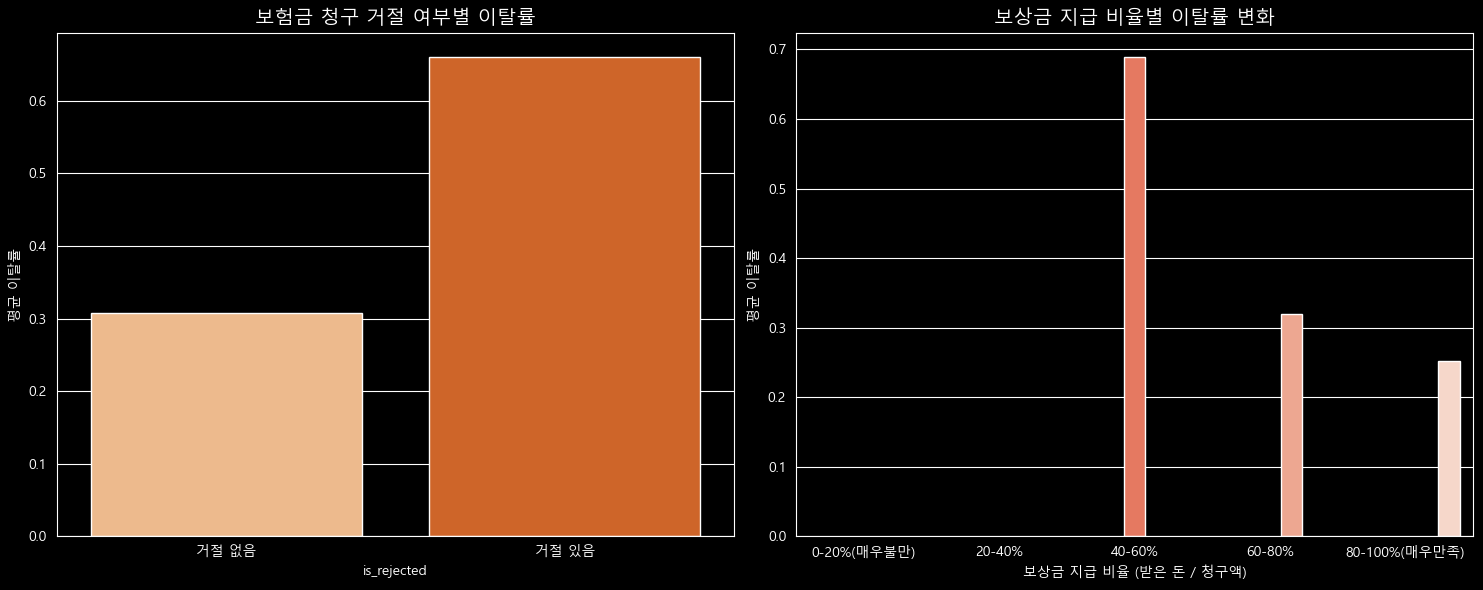

In [23]:
# 3. 가설 검증 시각화
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# [왼쪽] 거절 경험 유무에 따른 이탈률 비교
sns.barplot(data=eda_df, x='is_rejected', y='churn_flag', ax=ax[0],
            hue='is_rejected', palette='Oranges', legend=False, errorbar=None)
ax[0].set_title('보험금 청구 거절 여부별 이탈률', fontsize=14)
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['거절 없음', '거절 있음'])
ax[0].set_ylabel('평균 이탈률')

# [오른쪽] 지급 금액 비율(만족도)에 따른 이탈률 변화
sns.barplot(data=eda_df, x='payout_group', y='churn_flag', ax=ax[1],
            hue='payout_group', palette='Reds_r', legend=False, errorbar=None)
ax[1].set_title('보상금 지급 비율별 이탈률 변화', fontsize=14)
ax[1].set_xlabel('보상금 지급 비율 (받은 돈 / 청구액)')
ax[1].set_ylabel('평균 이탈률')

plt.tight_layout()
plt.show()

In [27]:
print("=== 가설 검증 데이터 결과 ===")
res1 = eda_df.groupby('is_rejected', observed=False)['churn_flag'].mean()
res2 = eda_df.groupby('payout_group', observed=False)['churn_flag'].mean()

print(f"거절 경험 고객 이탈률: {res1[True]:.2%}")
print(f"거절 미경험 고객 이탈률: {res1[False]:.2%}")
print("-" * 35)
print(f"매우 불만족(20%이하 수령) 고객 이탈률: {res2['0-20%(매우불만)']:.2%}")
print(f"매우 만족(80%이상 수령) 고객 이탈률: {res2['80-100%(매우만족)']:.2%}")

=== 가설 검증 데이터 결과 ===
거절 경험 고객 이탈률: 66.06%
거절 미경험 고객 이탈률: 30.75%
-----------------------------------
매우 불만족(20%이하 수령) 고객 이탈률: nan%
매우 만족(80%이상 수령) 고객 이탈률: 25.18%


## [1] 보상 거절 경험이 이탈에 미치는 영향
결론: 거절 경험은 이탈의 '결정적 트리거(Trigger)'임이 입증됨

거절 경험 고객 이탈률: 66.06%

거절 미경험 고객 이탈률: 30.75%

분석 결과: 보상 청구 시 거절(Rejection)을 한 번이라도 경험한 고객은 그렇지 않은 고객보다 이탈 위험이 약 2.15배 높습니다. 10명 중 6명 이상이 이탈하는 수준으로, 이탈 방지를 위한 최우선 관리 대상입니다.

## [2] 보상금 지급 만족도가 이탈에 미치는 영향
결론: 보상금이 높을수록 고객 유지(Retention) 효과가 뚜렷함

매우 만족(보상금 80% 이상 수령) 고객 이탈률: 25.18%

특이 사항: 보상금을 충분히 받은 고객은 전체 평균보다 훨씬 낮은 이탈률을 보입니다.

분석 결과: 지급 비율이 높을수록 이탈률이 낮아지는 '역상관관계'가 확인되었습니다. 즉, 보상금 규모가 고객의 심리적 보상 기전으로 작동하여 이탈을 억제하는 효과가 있습니다.

* 보상금 0~20% 구간에 데이터가 없었던 이유는 '거절 경험(is_rejected=True)' 집단과 이 구간이 거의 겹치기 때문입니다. 보고서에는 "보상금 20% 이하 수령군은 사실상 전액 거절 집단에 포함되어 별도의 이탈률을 산출하기 어려우나, 해당 성격의 고객들이 포함된 거절 집단에서 66%라는 매우 높은 이탈률이 관측되었습니다.